# 1 · Seeing every hen, feeder, and waterer

We're building a low-cost camera system that watches a pen of laying hens and automatically keeps track of how each bird is doing — is it eating, drinking, resting, or nesting?

The first job is simple to say and hard to do: **find every object that matters in the frame.** For us that's three things — the *hens*, the *feeder*, and the *waterer*. We use a **YOLOv12 instance-segmentation** model, which doesn't just draw a box around each object, it traces its exact outline (a pixel *mask*). Those clean outlines are what later let us read the paint mark on a hen's back and tell the birds apart.

This notebook runs that model on one real top-down frame from our barn.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

# Locate the repo root (folder holding pen_config.json) and make src/ + scripts/ importable.
ROOT = Path.cwd()
for _ in range(6):
    if (ROOT / "pen_config.json").exists():
        break
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "scripts"))

import cv2, json
import numpy as np
import matplotlib.pyplot as plt

DEMO = ROOT / "output" / "demo"
DEMO.mkdir(parents=True, exist_ok=True)

SEG_MODEL  = "models/poultry-seg-yolo12s-v2.pt"
POSE_MODEL = "models/hen_pose_yolo12s_aug_v6.pt"   # the freshly retrained pose model
STEM = "20260605_141702"                            # a daytime synchronized clip
CAM0 = ROOT / "dataset/treatment1/cam0" / f"{STEM}.mp4"   # top-down
CAM1 = ROOT / "dataset/treatment1/cam1" / f"{STEM}.mp4"   # lateral

def show(img_bgr, title="", w=11):
    """Show a BGR image inline."""
    h, wd = img_bgr.shape[:2]
    plt.figure(figsize=(w, w * h / wd))
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)); plt.axis("off")
    if title: plt.title(title, fontsize=13)
    plt.show()

def grab(video, idx=300):
    """Read one frame from a video."""
    cap = cv2.VideoCapture(str(video)); cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, fr = cap.read(); cap.release()
    if not ok: raise RuntimeError(f"could not read frame {idx} of {video}")
    return fr


In [2]:
from ultralytics import YOLO
seg = YOLO(SEG_MODEL)
print("classes:", seg.names)   # {0: feeder, 1: hen, 2: waterer}

FlashAttention is not available on this device. Using scaled_dot_product_attention instead.


classes: {0: 'feeder', 1: 'hen', 2: 'waterer'}


### Run segmentation on a top-down frame
The model returns, for each detected object, a class, a confidence, a box, and a pixel-level mask. We paint each mask in its class colour and label it.

detected: {'hen': 4}


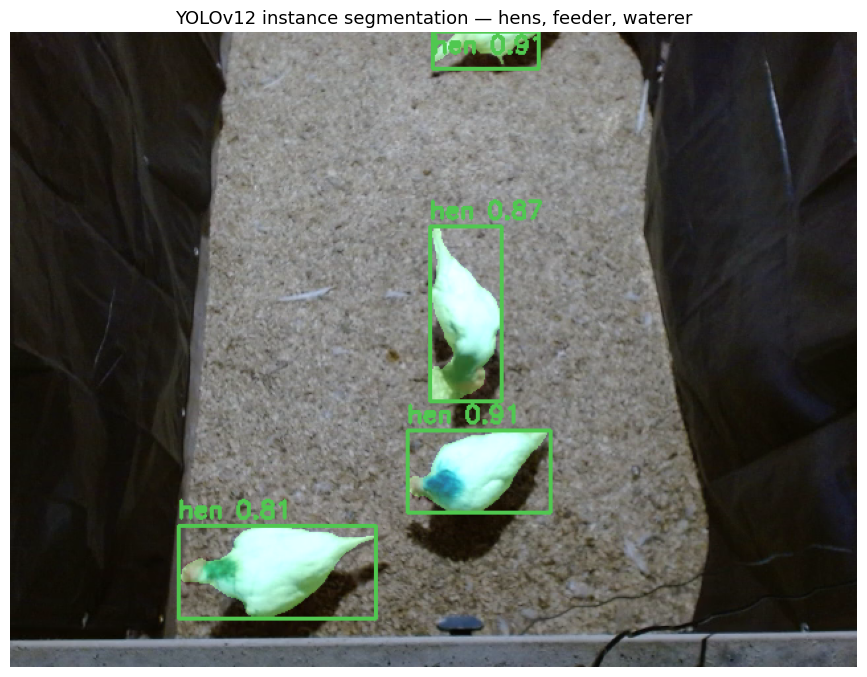

In [3]:
# per-class BGR colours
CLASS_BGR = {"hen": (80, 200, 80), "feeder": (40, 120, 240), "waterer": (240, 170, 40)}

def draw_seg(frame, res, alpha=0.45):
    """Overlay filled instance masks + boxes + labels."""
    out = frame.copy()
    names = res.names
    if res.masks is not None:
        for m, b in zip(res.masks.data.cpu().numpy(), res.boxes):
            cls = names[int(b.cls)]; col = CLASS_BGR.get(cls, (200, 200, 200))
            mask = cv2.resize(m, (frame.shape[1], frame.shape[0])) > 0.5
            layer = np.zeros_like(frame); layer[mask] = col
            out = cv2.addWeighted(out, 1.0, layer, alpha, 0)
    for b in res.boxes:
        cls = names[int(b.cls)]; col = CLASS_BGR.get(cls, (200, 200, 200))
        x1, y1, x2, y2 = b.xyxy[0].cpu().numpy().astype(int)
        cv2.rectangle(out, (x1, y1), (x2, y2), col, 2)
        cv2.putText(out, f"{cls} {float(b.conf):.2f}", (x1, max(16, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, col, 2)
    return out

frame = grab(CAM0, 300)
res = seg.predict(frame, conf=0.35, imgsz=1280, verbose=False)[0]
vis = draw_seg(frame, res)
cv2.imwrite(str(DEMO / "seg_frame.png"), vis)
n = {seg.names[int(b.cls)]: 0 for b in res.boxes}
for b in res.boxes: n[seg.names[int(b.cls)]] += 1
print("detected:", n)
show(vis, "YOLOv12 instance segmentation — hens, feeder, waterer")

### Why masks, not just boxes?
A bounding box would include a lot of litter and neighbouring birds. The **mask** isolates the bird itself — including the coloured paint on its back — which is the key to identifying *which* hen it is (next notebooks). On our held-out test set this model reaches a mask mAP@0.5 of about **0.98**.

The annotated image is saved to `output/demo/seg_frame.png` for sharing.